# NB5 — Integrated Models

**Purpose**: Combine all dimensions into multivariate models.  
Covers mixed-effects logistic regression, interaction effects, and mediation analysis.

> This is an exploratory notebook. Results should be interpreted with caution given the sample size.

---

In [1]:
# ── Imports & Setup ──
import sys, os, warnings
import numpy as np
import pandas as pd
from scipy import stats
import pingouin as pg
import statsmodels.api as sm
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from helpers import (
    load_and_clean, derive_variables, get_participant_summary,
    get_completers, setup_plotting, COLORS, CONDITION_PALETTE
)

plt, sns = setup_plotting()

df = load_and_clean()
df = derive_variables(df)

# Add within-phase trial for modeling
df['within_phase_trial'] = ((df['trial_order'] - 1) % 50) + 1
df['within_phase_trial_z'] = (df['within_phase_trial'] - 25) / 25  # center & scale

# Numeric condition for modeling
df['is_ai'] = df['ai_shown'].astype(int)

# KL severity as ordered numeric
kl_num_map = {'healthy': 0, 'mild': 1, 'moderate': 2, 'severe': 3}
df['kl_severity_num'] = df['kl_severity'].map(kl_num_map)

print(f'Total trials: {len(df)}, Participants: {df["participant_id"].nunique()}')

═══════════════════════════════════════════════════════
  RADIOLOGIST GROUND TRUTH APPLIED
  File: Radiologist_Ground_Truth.csv
═══════════════════════════════════════════════════════
  Amb images (KL1):  23 images, 2737 trials
  Action taken:      KEEP_AS_NEGATIVE
  Rows:              5950 → 5950
  Label flips:       1666 trials (14 images)
  Flipped images:    ['4.png', '5.png', '6.png', '10.png', '17.png', '20.png', '23.png', '24.png', '33.png', '36.png', '37.png', '41.png', '44.png', '49.png']
  New class balance: 0=3451  1=2499
═══════════════════════════════════════════════════════
Total trials: 5950, Participants: 68


## 1. Mixed-Effects Logistic Regression: Base Model

`user_correct ~ is_ai + within_phase_trial + kl_severity + (1 | participant_id)`

In [2]:
# Base model: accuracy predicted by condition, time, and difficulty
model_data = df[['user_correct', 'is_ai', 'within_phase_trial_z', 
                 'kl_severity_num', 'participant_id']].dropna()

print(f'Model data: {len(model_data)} trials, {model_data["participant_id"].nunique()} participants')

# Mixed-effects logistic regression
model1 = smf.mixedlm(
    'user_correct ~ is_ai + within_phase_trial_z + kl_severity_num',
    data=model_data,
    groups=model_data['participant_id']
).fit(reml=False)

print('=== Model 1: Base Mixed-Effects Model ===')
print(model1.summary())

Model data: 3213 trials, 68 participants
=== Model 1: Base Mixed-Effects Model ===
             Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  user_correct
No. Observations:    3213     Method:              ML          
No. Groups:          68       Scale:               0.1550      
Min. group size:     27       Log-Likelihood:      -1578.0423  
Max. group size:     54       Converged:           Yes         
Mean group size:     47.2                                      
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.684    0.015 45.799 0.000  0.655  0.713
is_ai                 0.025    0.014  1.742 0.082 -0.003  0.052
within_phase_trial_z -0.005    0.012 -0.388 0.698 -0.028  0.019
kl_severity_num       0.091    0.009 10.241 0.000  0.073  0.108
Group Var             0.002    0.0

/Users/martonbaltay/Documents/FeelGoodAI/Code/PerCoTate/public/scripts/dataAnalysis/venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


# 1.1 Mixed Logistic Regression (GLMM)

`user_correct ~ is_ai + within_phase_trial + kl_severity + (1 | participant_id)`

In [3]:
# Prepare data
model_data = df[['user_correct', 'is_ai', 'within_phase_trial_z',
                 'kl_severity_num', 'participant_id']].dropna()

print(f'Model data: {len(model_data)} trials, {model_data["participant_id"].nunique()} participants')


# --- Mixed Logistic Regression (GLMM) ---
# Random intercept per participant

model = sm.BinomialBayesMixedGLM.from_formula(
    "user_correct ~ is_ai + within_phase_trial_z + kl_severity_num",
    {"participant": "0 + C(participant_id)"},
    model_data
)

result = model.fit_vb()

print("=== Mixed Logistic Regression (GLMM) ===")
print(result.summary())

Model data: 3213 trials, 68 participants
=== Mixed Logistic Regression (GLMM) ===
                    Binomial Mixed GLM Results
                     Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
-------------------------------------------------------------------
Intercept               M     0.7026   0.0447                      
is_ai                   M     0.1612   0.0638                      
within_phase_trial_z    M    -0.0365   0.0779                      
kl_severity_num         M     0.6114   0.0384                      
participant             V    -1.2609   0.0862 0.283   0.239   0.337
Parameter types are mean structure (M) and variance structure (V)
Variance parameters are modeled as log standard deviations


## 2. Model with Interaction: Condition × Time

Does the fatigue effect differ by condition?

In [4]:
# Model 2: add interaction
model2 = smf.mixedlm(
    'user_correct ~ is_ai * within_phase_trial_z + kl_severity_num',
    data=model_data,
    groups=model_data['participant_id']
).fit(reml=False)

print('=== Model 2: With Condition × Time Interaction ===')
print(model2.summary())

# Compare models
print(f'\n--- Model Comparison ---')
print(f'Model 1 AIC: {model1.aic:.1f}, BIC: {model1.bic:.1f}')
print(f'Model 2 AIC: {model2.aic:.1f}, BIC: {model2.bic:.1f}')
print(f'Lower AIC/BIC = better fit')

=== Model 2: With Condition × Time Interaction ===
                Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    user_correct
No. Observations:      3213       Method:                ML          
No. Groups:            68         Scale:                 0.1550      
Min. group size:       27         Log-Likelihood:        -1578.0419  
Max. group size:       54         Converged:             Yes         
Mean group size:       47.2                                          
---------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                   0.684    0.015 45.780 0.000  0.655  0.713
is_ai                       0.025    0.014  1.738 0.082 -0.003  0.052
within_phase_trial_z       -0.005    0.017 -0.290 0.772 -0.039  0.029
is_ai:within_phase_trial_z  0.001    0.024  0.028 0.978

/Users/martonbaltay/Documents/FeelGoodAI/Code/PerCoTate/public/scripts/dataAnalysis/venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## 3. Model with Psychometrics

Add IQ and Big5 traits (only for participants with psychometric data).

In [5]:
# Model 3: add psychometrics (subset with psychometric data)
model3_data = df[df['has_psychometrics']].copy()
model3_data = model3_data[[
    'user_correct', 'is_ai', 'within_phase_trial_z', 'kl_severity_num',
    'participant_id', 'iq_score', 'big5_neuroticism', 'big5_conscientiousness'
]].dropna()

# Center psychometric variables
for col in ['iq_score', 'big5_neuroticism', 'big5_conscientiousness']:
    model3_data[f'{col}_c'] = model3_data[col] - model3_data[col].mean()

print(f'Model 3 data: {len(model3_data)} trials, {model3_data["participant_id"].nunique()} participants')

model3 = smf.mixedlm(
    'user_correct ~ is_ai * within_phase_trial_z + kl_severity_num + iq_score_c + big5_neuroticism_c + big5_conscientiousness_c',
    data=model3_data,
    groups=model3_data['participant_id']
).fit(reml=False)

print('=== Model 3: With Psychometrics ===')
print(model3.summary())

Model 3 data: 2943 trials, 58 participants


/Users/martonbaltay/Documents/FeelGoodAI/Code/PerCoTate/public/scripts/dataAnalysis/venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/martonbaltay/Documents/FeelGoodAI/Code/PerCoTate/public/scripts/dataAnalysis/venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/martonbaltay/Documents/FeelGoodAI/Code/PerCoTate/public/scripts/dataAnalysis/venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


=== Model 3: With Psychometrics ===
                Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    user_correct
No. Observations:      2943       Method:                ML          
No. Groups:            58         Scale:                 0.1557      
Min. group size:       27         Log-Likelihood:        -1450.1547  
Max. group size:       54         Converged:             Yes         
Mean group size:       50.7                                          
---------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                   0.686    0.015 45.183 0.000  0.657  0.716
is_ai                       0.024    0.015  1.615 0.106 -0.005  0.053
within_phase_trial_z       -0.005    0.017 -0.276 0.782 -0.039  0.029
is_ai:within_phase_trial_z -0.007    0.025 -0.275 0.784 -0.057  0.043


/Users/martonbaltay/Documents/FeelGoodAI/Code/PerCoTate/public/scripts/dataAnalysis/venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


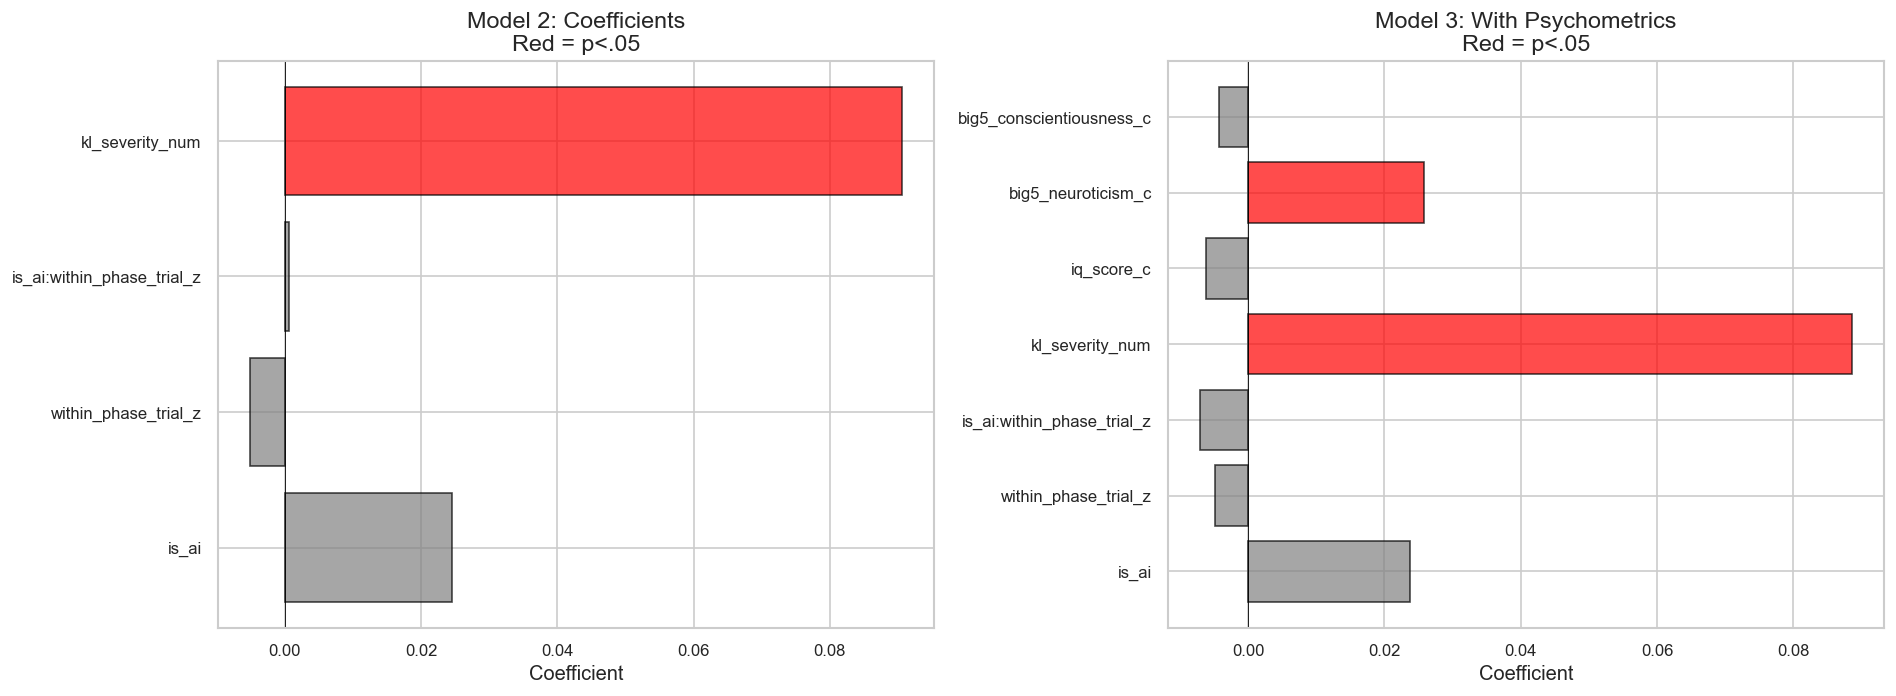

In [6]:
# Visualization: coefficient comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Model 1 vs Model 2 coefficients (shared predictors)
for model, label, ax_idx in [(model1, 'Base Model', 0), (model2, 'Interaction Model', 0)]:
    coefs = model.params.drop('Intercept', errors='ignore')
    coefs = coefs.drop('Group Var', errors='ignore')
    pass  # Models plotted together below

# Model 2 coefficients
coefs2 = model2.params.drop(['Intercept', 'Group Var'], errors='ignore')
ci2 = model2.conf_int().drop(['Intercept', 'Group Var'], errors='ignore')
pvals2 = model2.pvalues.drop(['Intercept', 'Group Var'], errors='ignore')

colors2 = ['red' if p < 0.05 else 'gray' for p in pvals2]
y_pos = range(len(coefs2))
axes[0].barh(y_pos, coefs2.values, color=colors2, alpha=0.7, edgecolor='black')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(coefs2.index)
axes[0].axvline(x=0, color='black', linewidth=0.5)
axes[0].set_title('Model 2: Coefficients\nRed = p<.05')
axes[0].set_xlabel('Coefficient')

# Model 3 coefficients
coefs3 = model3.params.drop(['Intercept', 'Group Var'], errors='ignore')
pvals3 = model3.pvalues.drop(['Intercept', 'Group Var'], errors='ignore')

colors3 = ['red' if p < 0.05 else 'gray' for p in pvals3]
y_pos = range(len(coefs3))
axes[1].barh(y_pos, coefs3.values, color=colors3, alpha=0.7, edgecolor='black')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(coefs3.index)
axes[1].axvline(x=0, color='black', linewidth=0.5)
axes[1].set_title('Model 3: With Psychometrics\nRed = p<.05')
axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

## 4. Mediation Analysis: Does Confidence Mediate AI → Accuracy?

Path: AI assistance → User confidence → Accuracy

In [7]:
# Simple mediation analysis
# Step 1: AI → Accuracy (total effect, path c)
# Step 2: AI → Confidence (path a)  
# Step 3: AI + Confidence → Accuracy (path c' and b)
# Mediation if: c significant, a significant, b significant, c' reduced

med_data = df[['user_correct', 'is_ai', 'user_confidence', 'participant_id']].dropna()

print('=== Mediation Analysis: AI → Confidence → Accuracy ===')
print(f'n = {len(med_data)} trials\n')

# Path c: AI → Accuracy
c_model = smf.mixedlm('user_correct ~ is_ai', data=med_data, 
                       groups=med_data['participant_id']).fit(reml=False)
print(f'Path c (AI → Accuracy): β={c_model.params["is_ai"]:.4f}, p={c_model.pvalues["is_ai"]:.4f}')

# Path a: AI → Confidence
a_model = smf.mixedlm('user_confidence ~ is_ai', data=med_data,
                       groups=med_data['participant_id']).fit(reml=False)
print(f'Path a (AI → Confidence): β={a_model.params["is_ai"]:.4f}, p={a_model.pvalues["is_ai"]:.4f}')

# Path c' and b: AI + Confidence → Accuracy
med_model = smf.mixedlm('user_correct ~ is_ai + user_confidence', data=med_data,
                         groups=med_data['participant_id']).fit(reml=False)
print(f"Path c' (AI → Accuracy, controlling for confidence): β={med_model.params['is_ai']:.4f}, p={med_model.pvalues['is_ai']:.4f}")
print(f'Path b (Confidence → Accuracy, controlling for AI): β={med_model.params["user_confidence"]:.4f}, p={med_model.pvalues["user_confidence"]:.4f}')

# Indirect effect (a × b)
indirect = a_model.params['is_ai'] * med_model.params['user_confidence']
total = c_model.params['is_ai']
proportion_mediated = indirect / total if total != 0 else 0

print(f'\nIndirect effect (a × b): {indirect:.4f}')
print(f'Total effect (c): {total:.4f}')
print(f'Proportion mediated: {proportion_mediated:.1%}')
print(f'\n⚠️  For formal mediation, consider bootstrap CIs (e.g., via process or custom bootstrap)')

=== Mediation Analysis: AI → Confidence → Accuracy ===
n = 5950 trials

Path c (AI → Accuracy): β=0.0005, p=0.9688
Path a (AI → Confidence): β=-0.0353, p=0.3167
Path c' (AI → Accuracy, controlling for confidence): β=0.0055, p=0.6517
Path b (Confidence → Accuracy, controlling for AI): β=0.0840, p=0.0000

Indirect effect (a × b): -0.0030
Total effect (c): 0.0005
Proportion mediated: -616.6%

⚠️  For formal mediation, consider bootstrap CIs (e.g., via process or custom bootstrap)


/Users/martonbaltay/Documents/FeelGoodAI/Code/PerCoTate/public/scripts/dataAnalysis/venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/martonbaltay/Documents/FeelGoodAI/Code/PerCoTate/public/scripts/dataAnalysis/venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## 5. Model Summary & Comparison

In [8]:
# Summary table
summary = pd.DataFrame({
    'Model': ['M1: Base', 'M2: + Interaction', 'M3: + Psychometrics'],
    'n_trials': [len(model_data), len(model_data), len(model3_data)],
    'n_participants': [model_data['participant_id'].nunique(), 
                      model_data['participant_id'].nunique(),
                      model3_data['participant_id'].nunique()],
    'AIC': [model1.aic, model2.aic, model3.aic],
    'BIC': [model1.bic, model2.bic, model3.bic],
    'AI_effect_p': [model1.pvalues.get('is_ai', np.nan),
                    model2.pvalues.get('is_ai', np.nan),
                    model3.pvalues.get('is_ai', np.nan)],
})

print('=== Model Comparison ===')
display(summary.round(3))

=== Model Comparison ===


,Model,n_trials,n_participants,AIC,BIC,AI_effect_p
0,M1: Base,3213,68,3168.085,3204.534,0.082
1,M2: + Interaction,3213,68,3170.084,3212.609,0.082
2,M3: + Psychometrics,2943,58,2920.309,2980.181,0.106


## Findings & Next Steps

**Summarize after running:**

1. Does AI condition significantly predict accuracy after controlling for time and difficulty?
2. Is there a condition × time interaction (differential fatigue)?
3. Do psychometric variables add predictive value?
4. Does confidence mediate the AI → accuracy relationship?
5. Which model fits best based on AIC/BIC?

---

**Pipeline complete.** All analyses from NB0–NB5 provide a comprehensive, defensible investigation of the PerCoTate experiment.